## Question 1
A researcher gathers information about the patterns of Physical Activity of children in the fifth grade of primary school of a public school. He defines three categories of physical activity (Low, Medium, High). He also inquires about the regular consumption of sugary drinks at school, and defines two categories (Yes = consumed, No = not consumed). We would like to evaluate if there is an association between patterns of physical activity and the consumption of sugary drinks for the children of this school, at a level of 5% significance. The results are in the following table: 

![](table4.png)

In [1]:
# your answer here

import numpy as np
from scipy import stats

# ----------------------------------------------------------
# CHI-SQUARE TEST OF INDEPENDENCE
# ----------------------------------------------------------
# We want to know: is there a relationship between
# physical activity level and sugary drink consumption?
#
# H0 (null hypothesis):      Physical activity and sugary drinks are INDEPENDENT
#                            (no association between them)
# H1 (alternative):          There IS an association between them
#
# Significance level: alpha = 0.05
# ----------------------------------------------------------

# Observed frequencies from the table
# Rows = Physical Activity: Low, Medium, High
# Cols = Sugary Drinks:     Yes, No
observed = np.array([
    [32, 12],   # Low activity
    [14, 22],   # Medium activity
    [ 6,  9],   # High activity
])

# scipy calculates everything for us:
# - chi2 statistic
# - p-value
# - degrees of freedom = (rows-1)(cols-1) = (3-1)(2-1) = 2
# - expected frequencies under H0
chi2, p_value, dof, expected = stats.chi2_contingency(observed)

print('=== Chi-Square Test of Independence ===')
print(f'Chi-square statistic : {chi2:.4f}')
print(f'Degrees of freedom   : {dof}')
print(f'p-value              : {p_value:.4f}')
print(f'Critical value (0.05): {stats.chi2.ppf(0.95, dof):.4f}')
print()
print('Expected frequencies (under H0 — if truly independent):')
print(f'  Low    → Yes: {expected[0,0]:.2f}  No: {expected[0,1]:.2f}')
print(f'  Medium → Yes: {expected[1,0]:.2f}  No: {expected[1,1]:.2f}')
print(f'  High   → Yes: {expected[2,0]:.2f}  No: {expected[2,1]:.2f}')

=== Chi-Square Test of Independence ===
Chi-square statistic : 10.7122
Degrees of freedom   : 2
p-value              : 0.0047
Critical value (0.05): 5.9915

Expected frequencies (under H0 — if truly independent):
  Low    → Yes: 24.08  No: 19.92
  Medium → Yes: 19.71  No: 16.29
  High   → Yes: 8.21  No: 6.79


In [2]:
# ----------------------------------------------------------
# DECISION
# ----------------------------------------------------------
# Two ways to decide — both give the same answer:
#   1. p-value < alpha  → reject H0
#   2. chi2 > critical value → reject H0
# ----------------------------------------------------------

alpha = 0.05

print('=== Decision ===')
print(f'p-value ({p_value:.4f}) vs alpha ({alpha})')

if p_value < alpha:
    print(f'\np-value < alpha → REJECT H0')
    print('\nConclusion:')
    print('At a 5% significance level, there IS a statistically significant')
    print('association between physical activity patterns and sugary drink consumption.')
    print()
    print('Looking at the data: children with LOW physical activity consume')
    print('sugary drinks more (32 Yes vs 12 No), while children with MEDIUM')
    print('and HIGH activity tend to consume less. This pattern is not random.')
else:
    print(f'\np-value >= alpha → FAIL TO REJECT H0')
    print('No significant association found at the 5% level.')

=== Decision ===
p-value (0.0047) vs alpha (0.05)

p-value < alpha → REJECT H0

Conclusion:
At a 5% significance level, there IS a statistically significant
association between physical activity patterns and sugary drink consumption.

Looking at the data: children with LOW physical activity consume
sugary drinks more (32 Yes vs 12 No), while children with MEDIUM
and HIGH activity tend to consume less. This pattern is not random.


## [OPTIONAL] Question 2
The following table indicates the number of 6-point scores in an American rugby match in the 1979 season.

![](table1.png)

Based on these results, we create a Poisson distribution with the sample mean parameter  = 2.435. Is there any reason to believe that at a .05 level the number of scores is a Poisson variable?

Check [here](https://www.geeksforgeeks.org/how-to-create-a-poisson-probability-mass-function-plot-in-python/) how to create a poisson distribution and how to calculate the expected observations, using the probability mass function (pmf). 
A Poisson distribution is a discrete probability distribution. It gives the probability of an event happening a certain number of times (k) within a given interval of time or space. The Poisson distribution has only one parameter, λ (lambda), which is the mean number of events.

In [4]:
# your answer here

# ----------------------------------------------------------
# GOODNESS OF FIT TEST — does the data follow Poisson?
# ----------------------------------------------------------
# H0: The number of scores follows a Poisson distribution (λ=2.435)
# H1: The data does NOT follow a Poisson distribution
#
# Significance level: alpha = 0.05
# ----------------------------------------------------------

import matplotlib.pyplot as plt

lam = 2.435   # given sample mean
n   = 448     # total matches

# Observed frequencies from the table
# We merge '6' and '7 or more' into one category '6+'
# because expected counts must be >= 5 for chi-square to be valid
observed_counts = [35, 99, 104, 110, 62, 25, 10+3]  # 6+ merges 10 and 3
labels          = ['0', '1', '2', '3', '4', '5', '6+']

# Calculate EXPECTED counts using the Poisson PMF
# P(X=k) = e^(-λ) * λ^k / k!
# For category 6+: P(X>=6) = 1 - P(X<=5) — we use the CDF
probs = [stats.poisson.pmf(k, lam) for k in range(6)]
probs.append(1 - stats.poisson.cdf(5, lam))   # P(X >= 6)

expected_counts = [p * n for p in probs]

print('=== Observed vs Expected ===')
print(f'{"Scores":<10} {"Observed":>10} {"Expected":>10}')
print('-' * 32)
for lab, obs, exp in zip(labels, observed_counts, expected_counts):
    print(f'{lab:<10} {obs:>10} {exp:>10.2f}')
print(f'{"Total":<10} {sum(observed_counts):>10} {sum(expected_counts):>10.2f}')

=== Observed vs Expected ===
Scores       Observed   Expected
--------------------------------
0                  35      39.24
1                  99      95.56
2                 104     116.34
3                 110      94.43
4                  62      57.49
5                  25      28.00
6+                 13      16.94
Total             448     448.00


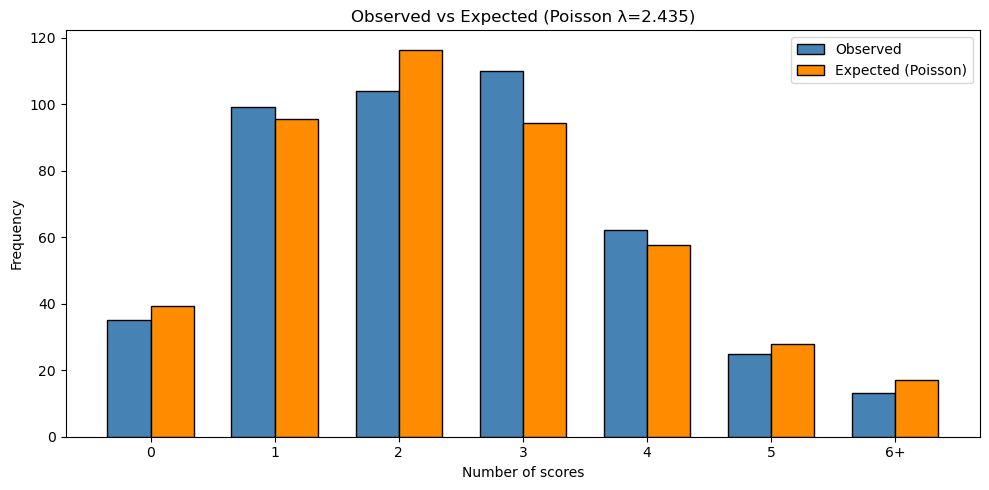

In [5]:
# your answer here

# Visual comparison
x = range(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar([i - width/2 for i in x], observed_counts, width, label='Observed', color='steelblue', edgecolor='black')
ax.bar([i + width/2 for i in x], expected_counts,  width, label='Expected (Poisson)', color='darkorange', edgecolor='black')
ax.set_xticks(list(x))
ax.set_xticklabels(labels)
ax.set_xlabel('Number of scores')
ax.set_ylabel('Frequency')
ax.set_title('Observed vs Expected (Poisson λ=2.435)')
ax.legend()
plt.tight_layout()
plt.show()

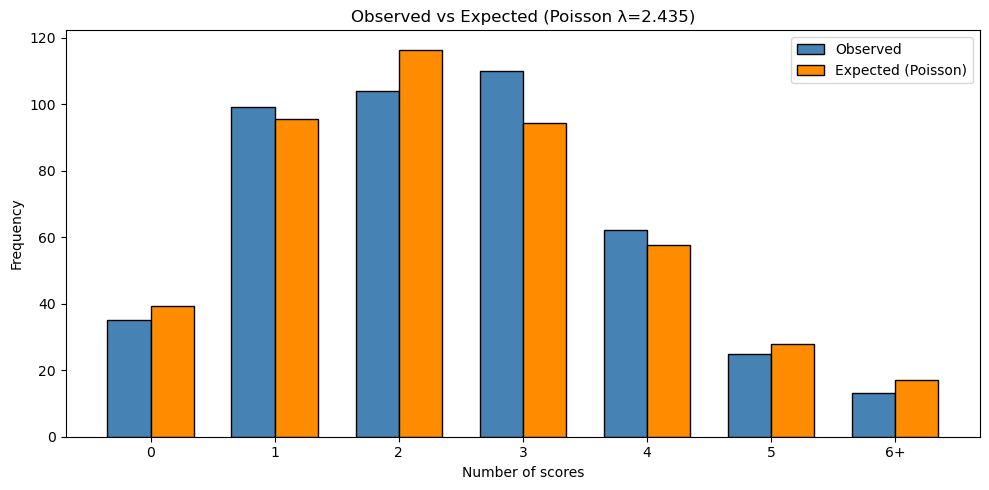

In [5]:
# your answer here



In [6]:
# Chi-square goodness of fit test
# Degrees of freedom = categories - 1 - estimated_parameters
#                    = 7 - 1 - 1 (lambda was estimated from data) = 5
chi2_gof, p_gof = stats.chisquare(observed_counts, f_exp=expected_counts)
dof_gof = len(observed_counts) - 1 - 1

print('=== Goodness of Fit Test ===')
print(f'Chi-square statistic : {chi2_gof:.4f}')
print(f'Degrees of freedom   : {dof_gof}')
print(f'p-value              : {p_gof:.4f}')
print(f'Critical value (0.05): {stats.chi2.ppf(0.95, dof_gof):.4f}')

alpha = 0.05
print()
if p_gof < alpha:
    print(f'p-value ({p_gof:.4f}) < alpha → REJECT H0')
    print('The data does NOT follow a Poisson distribution.')
else:
    print(f'p-value ({p_gof:.4f}) >= alpha → FAIL TO REJECT H0')
    print()
    print('Conclusion:')
    print('At the 0.05 level, there is NO reason to believe that the')
    print('number of scores is NOT a Poisson variable.')
    print('The data is consistent with a Poisson distribution (λ=2.435).')

=== Goodness of Fit Test ===
Chi-square statistic : 6.0517
Degrees of freedom   : 5
p-value              : 0.4174
Critical value (0.05): 11.0705

p-value (0.4174) >= alpha → FAIL TO REJECT H0

Conclusion:
At the 0.05 level, there is NO reason to believe that the
number of scores is NOT a Poisson variable.
The data is consistent with a Poisson distribution (λ=2.435).
